In [1]:
!pip install --quiet pydicom nibabel scikit-image tqdm shap streamlit pyradiomics

# ============================================
# GLOBAL TOGGLES FOR ADVANCED PIPELINE
# ============================================
ENABLE_RADIOMICS = True          # turn ON full radiomics pipeline
ENABLE_PYRADIOMICS = True        # use PyRadiomics when masks are available
ENABLE_RAD_AE = True             # train RadiomicsAE_256D_v1
ENABLE_SEG_MASKS = True          # consume nnU-Net / TotalSegmentator masks if present

import nibabel as nib
try:
    from radiomics import featureextractor
    _PYRAD_AVAILABLE = True
except ImportError:
    _PYRAD_AVAILABLE = False
    print("[warn] PyRadiomics not available, falling back to light radiomics")

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras import layers, models

import shap
import matplotlib.pyplot as plt
import joblib



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 43.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 59.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
[warn] PyRadiomics not available, falling back to light radiomics


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
%%shell
#rsync -av --progress "/content/drive/MyDrive/capstone/tumor_pred_ai/DataSet/RawData-M" "/content/capstone/DataSet"
#cd "/content/drive/MyDrive/capstone/tumor_pred_ai/DataSet/"
#tar -cf rawdata_m.tar RawData-M
cp "/content/drive/MyDrive/capstone/tumor_pred_ai/DataSet/rawdata_m.tar" "/content/"
cd /content
tar -xf rawdata_m.tar




In [5]:
# ============================================
# 0) SETUP & IMPORTS
# ============================================
!pip install --quiet pydicom nibabel scikit-image tqdm shap



from pathlib import Path
import os, random, math
import numpy as np
import pandas as pd
import pydicom
from tqdm import tqdm
from scipy.ndimage import zoom as ndzoom
from collections import defaultdict
import concurrent.futures

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras import layers, models

import shap
import matplotlib.pyplot as plt

# reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# let TF not grab the whole GPU at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except Exception as e:
        print("Could not set memory growth:", e)
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.5 MB/s eta 0:00:00
GPU memory growth enabled.
TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# ============================================
# 1) PATHS
# ============================================
PROJECT_ROOT = Path("/content")
RAW_DIR_CANDIDATE = PROJECT_ROOT / "RawData-M"
CLINICAL_CSV = RAW_DIR_CANDIDATE / "C4KC-KiTS_Clinical-Data_Version_m.csv"
META_CSV     = RAW_DIR_CANDIDATE / "metadata_m.csv"
IMAGE_ROOT   = RAW_DIR_CANDIDATE / "C4KC-KiTS"

if not CLINICAL_CSV.exists():
    raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}")
clinical_df = pd.read_csv(CLINICAL_CSV)

if META_CSV.exists():
    meta_df = pd.read_csv(META_CSV)
else:
    meta_df = None
    print("[warn] metadata CSV not found, continuing with clinical only")

# detect id columns
id_candidates = [c for c in clinical_df.columns
                 if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
clinical_id_col = id_candidates[0] if id_candidates else clinical_df.columns[0]
print("Clinical ID column:", clinical_id_col)

if meta_df is not None:
    meta_id_candidates = [c for c in meta_df.columns
                          if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    meta_id_col = meta_id_candidates[0] if meta_id_candidates else meta_df.columns[0]
    merged_df = pd.merge(clinical_df, meta_df,
                         left_on=clinical_id_col,
                         right_on=meta_id_col,
                         how='left')
    join_key = clinical_id_col
    print("Merged shape:", merged_df.shape)
else:
    merged_df = clinical_df.copy()
    join_key = clinical_id_col
    print("Clinical only shape:", merged_df.shape)

if not IMAGE_ROOT.exists():
    raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")


Clinical ID column: patient_id
Merged shape: (40, 77)


In [7]:
# Optional directory for precomputed segmentation masks (e.g., nnU-Net / TotalSegmentator outputs)
MASK_ROOT = RAW_DIR_CANDIDATE / "SegMasks"  # e.g., one NIfTI per patient_id
print("MASK_ROOT:", MASK_ROOT)

def load_seg_mask(patient_id: str):
    """
    Load precomputed segmentation mask for this patient, if available.
    Expected: MASK_ROOT / <patient_id>.nii.gz or .nii or .npy
    Returns mask volume in (Z,H,W) or None.
    """
    if not ENABLE_SEG_MASKS or not MASK_ROOT.exists():
        return None

    # candidates
    base = MASK_ROOT / str(patient_id)
    possible_paths = [
        MASK_ROOT / f"{patient_id}.nii.gz",
        MASK_ROOT / f"{patient_id}.nii",
        MASK_ROOT / f"{patient_id}.npy",
        base / "mask.nii.gz",
        base / "mask.nii",
        base / "mask.npy",
    ]
    for p in possible_paths:
        if p.exists():
            if p.suffix == ".npy":
                m = np.load(p)
            else:
                nii = nib.load(str(p))
                m = nii.get_fdata()
            m = np.asarray(m)
            # ensure (Z,H,W)
            if m.ndim == 3:
                return m.astype(bool)
            elif m.ndim == 4:  # sometimes (Z,H,W,1)
                return m[..., 0].astype(bool)
    return None


MASK_ROOT: /content/RawData-M/SegMasks


In [9]:
# ============================================
# 2) GLOBAL PREPROCESS PARAMS
# ============================================
CLIP_HU = (-200, 300)
# smaller target to reduce memory, using (H,W,D) later
TARGET_SHAPE = (96, 96, 48)   # H, W, D in final tensor
PROCESS_LIMIT = None          # set e.g. 20 if you want quick test

MAX_WORKERS = min(8, os.cpu_count() or 8)
PATIENTS_PER_CHUNK = 200


# ============================================
# 3) DICOM + RADIOMICS HELPERS
# ============================================
def clip_and_normalize_hu(vol, clip=CLIP_HU):
    v = np.clip(vol, clip[0], clip[1]).astype(np.float32)
    v = (v - clip[0]) / (clip[1] - clip[0] + 1e-9)
    return v
def compute_pyradiomics_features(vol, spacing, mask):
    """
    Use PyRadiomics to compute rich radiomics features from a (Z,H,W) volume and mask.
    Returns dict of {feature_name: value}.
    """
    if not (ENABLE_PYRADIOMICS and _PYRAD_AVAILABLE):
        return {}

    # convert to NIfTI in memory
    # PyRadiomics expects image + mask files, but can also take SimpleITK images.
    import SimpleITK as sitk

    # vol: (Z,H,W)
    img_sitk = sitk.GetImageFromArray(vol.astype(np.float32))
    img_sitk.SetSpacing((float(spacing[2]), float(spacing[1]), float(spacing[0])))  # (dx, dy, dz)

    mask_sitk = sitk.GetImageFromArray(mask.astype(np.uint8))
    mask_sitk.CopyInformation(img_sitk)

    params = {"binWidth": 25, "resampledPixelSpacing": None, "interpolator": "sitkBSpline"}
    extractor = featureextractor.RadiomicsFeatureExtractor(**params)

    try:
        result = extractor.execute(img_sitk, mask_sitk)
    except Exception as e:
        print("[warn] PyRadiomics failed:", e)
        return {}

    feats = {}
    for k, v in result.items():
        # filter out non-feature keys
        if k.startswith("original_"):
            feats[k] = float(v) if np.isscalar(v) else float(v[0])
    return feats

def resize_volume_to_target_phys(vol, spacing, target_shape=TARGET_SHAPE):
    """
    vol: (Z,H,W) in HU
    spacing: (dz, dy, dx)
    target_shape: (H, W, D) for final model input
    """
    if vol is None:
        th, tw, td = target_shape
        return np.zeros((th, tw, td), dtype=np.float32)

    z, h, w = vol.shape
    th, tw, td = target_shape

    # first resize to (td, th, tw) on (Z,H,W)
    zoom_factors = (
        td / (z if z > 0 else 1),
        th / (h if h > 0 else 1),
        tw / (w if w > 0 else 1),
    )
    try:
        vr = ndzoom(vol, zoom_factors, order=1)  # (td, th, tw)
    except Exception as e:
        print("[warn] zoom failed:", e)
        return np.zeros((th, tw, td), dtype=np.float32)

    # transpose to (H,W,D)
    vr = np.transpose(vr, (1, 2, 0))
    return vr

# robust DICOM loader (2D slices only)
def load_dicom_series_to_volume(folder: Path):
    folder = Path(folder)
    files = sorted(folder.glob("*.dcm"))
    if not files:
        files = sorted(folder.rglob("*.dcm"))
    if not files:
        return None

    candidate_slices = []
    for f in files:
        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=False, force=True)
            if hasattr(ds, 'pixel_array') and ds.pixel_array is not None and ds.pixel_array.size > 0:
                if ds.pixel_array.ndim == 2:
                    candidate_slices.append(ds)
        except Exception:
            continue
    if not candidate_slices:
        return None

    # group by shape
    slices_by_shape = defaultdict(list)
    for s in candidate_slices:
        slices_by_shape[s.pixel_array.shape].append(s)

    if not slices_by_shape:
        return None

    most_common_shape = max(slices_by_shape, key=lambda shape: len(slices_by_shape[shape]))
    good_slices = slices_by_shape[most_common_shape]

    if len(good_slices) < 3:
        return None

    def zpos(s):
        try:
            return float(s.ImagePositionPatient[2])
        except:
            return None

    good_slices.sort(key=lambda s: (zpos(s) is None, zpos(s), getattr(s, 'InstanceNumber', 1)))

    vol = np.stack([s.pixel_array for s in good_slices]).astype(np.int16)
    for i, s in enumerate(good_slices):
        slope = float(getattr(s, 'RescaleSlope', 1.0))
        intercept = float(getattr(s, 'RescaleIntercept', 0.0))
        vol[i] = (vol[i].astype(np.float32) * slope + intercept).astype(np.int16)

    try:
        ps = good_slices[0].PixelSpacing
        dz = float(getattr(good_slices[0], 'SliceThickness', 1.0))
        spacing = (dz, float(ps[0]), float(ps[1]))
    except Exception:
        spacing = (1.0, 1.0, 1.0)

    return vol, spacing

# radiomics helpers (light)
try:
    from skimage.filters import threshold_otsu
    from skimage.feature import graycomatrix, graycoprops
    from skimage.measure import marching_cubes, label as sk_label
    _SKIMAGE_AVAILABLE = True
except ImportError:
    _SKIMAGE_AVAILABLE = False
    print("[warn] skimage not available, radiomics will be zeros")

def _hu_to_uint8(vol, hu_range=(-200, 300)):
    vol = np.nan_to_num(vol, nan=0.0, posinf=hu_range[1], neginf=hu_range[0])
    lo, hi = hu_range
    if hi <= lo:
        hi = lo + 1
    v = np.clip(vol, lo, hi)
    v = (255.0 * (v - lo) / (hi - lo)).astype(np.uint8)
    return v

def _quick_mask(vol_hwd, hu_range=(-200, 300)):
    if not _SKIMAGE_AVAILABLE:
        return np.zeros_like(vol_hwd, dtype=bool)
    v8 = _hu_to_uint8(vol_hwd, hu_range)
    try:
        t = threshold_otsu(v8)
    except Exception:
        t = 1
    m = (v8 >= t).astype(np.uint8)
    lab = sk_label(m)
    if lab.max() == 0:
        return m.astype(bool)
    counts = np.bincount(lab.ravel())
    if counts.size > 1:
        largest = counts[1:].argmax() + 1
        return (lab == largest)
    else:
        return m.astype(bool)

def _glcm_feats(slice_u8, distances=(1,2,3), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    if not _SKIMAGE_AVAILABLE:
        return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }
    if slice_u8.max() == slice_u8.min() or slice_u8.size < 2:
        return {
            'glcm_contrast': 0.0, 'glcm_dissim': 0.0, 'glcm_homo': 1.0,
            'glcm_energy': 1.0, 'glcm_corr': 1.0, 'glcm_ASM': 1.0
        }
    try:
        g = graycomatrix(slice_u8, distances=distances, angles=angles,
                         levels=256, symmetric=True, normed=True)
        feats = {
            'glcm_contrast':   float(graycoprops(g, 'contrast').mean()),
            'glcm_dissim':     float(graycoprops(g, 'dissimilarity').mean()),
            'glcm_homo':       float(graycoprops(g, 'homogeneity').mean()),
            'glcm_energy':     float(graycoprops(g, 'energy').mean()),
            'glcm_corr':       float(graycoprops(g, 'correlation').mean()),
            'glcm_ASM':        float(graycoprops(g, 'ASM').mean()),
        }
        return feats
    except Exception:
        return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }

def compute_light_radiomics(vol, spacing=(1.0, 1.0, 1.0), mask=None):
    """
    vol: (Z,H,W) float HU
    spacing: (dz, dy, dx)
    returns dict of intensity + shape + texture
    """
    if not _SKIMAGE_AVAILABLE:
        return {
            'int_mean': np.nan,'int_std': np.nan,'int_min': np.nan,'int_max': np.nan,'int_skew': np.nan,'int_kurt': np.nan,
            'shape_volume_mm3': np.nan, 'shape_surface_mm2': np.nan, 'shape_sphericity': np.nan,
            'glcm_contrast': np.nan,'glcm_dissim': np.nan,'glcm_homo': np.nan,'glcm_energy': np.nan,'glcm_corr': np.nan,'glcm_ASM': np.nan
        }

    vol = np.asarray(vol, dtype=np.float32)             # (Z,H,W)
    vol_hwd = np.transpose(vol, (1, 2, 0))              # (H,W,D)
    spacing_hwd = (spacing[1], spacing[2], spacing[0])  # (dy, dx, dz)

    if mask is None:
        mask = _quick_mask(vol_hwd)
    else:
        mask = mask.astype(bool)

    vox = vol_hwd[mask]
    if vox.size == 0:
        stats = {'int_mean':0.0,'int_std':0.0,'int_min':0.0,'int_max':0.0,'int_skew':0.0,'int_kurt':0.0}
    else:
        mu = float(np.mean(vox))
        sd = float(np.std(vox))
        if sd < 1e-6:
            z = np.zeros_like(vox)
        else:
            z = (vox - mu) / sd
        skew_val = np.mean(z**3)
        kurt_val = np.mean(z**4) - 3
        stats = {
            'int_mean': mu,
            'int_std' : sd,
            'int_min' : float(np.min(vox)),
            'int_max' : float(np.max(vox)),
            'int_skew': float(skew_val if np.isfinite(skew_val) else 0.0),
            'int_kurt': float(kurt_val if np.isfinite(kurt_val) else 0.0),
        }

    # shape via marching cubes
    try:
        verts, faces, _, _ = marching_cubes(mask.astype(float), level=0.5, spacing=spacing_hwd)
        tri = verts[faces]
        a = np.linalg.norm(tri[:,1]-tri[:,0], axis=1)
        b = np.linalg.norm(tri[:,2]-tri[:,1], axis=1)
        c = np.linalg.norm(tri[:,0]-tri[:,2], axis=1)
        s = 0.5*(a+b+c)
        area = float(np.sum(np.sqrt(np.clip(s*(s-a)*(s-b)*(s-c), 0, None))))
    except Exception:
        area = 0.0

    vol_mm3 = float(mask.sum() * float(np.prod(spacing_hwd)))

    if area > 1e-6 and vol_mm3 > 0:
        sphericity = (np.pi**(1/3)) * ((6*vol_mm3)**(2/3)) / (area + 1e-6)
        sphericity = float(sphericity if np.isfinite(sphericity) else 0.0)
    else:
        sphericity = 0.0

    shape = {'shape_volume_mm3': vol_mm3, 'shape_surface_mm2': area, 'shape_sphericity': sphericity}

    v8 = _hu_to_uint8(vol_hwd)
    D = vol_hwd.shape[2]
    mids = sorted(list({max(0, min(D-1, D//4)),
                        max(0, min(D-1, D//2)),
                        max(0, min(D-1, 3*D//4))}))
    glcms = []
    for k in mids:
        sl = v8[:, :, k]
        msl = mask[:, :, k]
        if np.count_nonzero(msl) >= 25:
            glcms.append(_glcm_feats(sl))
    if glcms:
        tex = {}
        feature_keys = glcms[0].keys()
        for k in feature_keys:
            vals = [d[k] for d in glcms if not np.isnan(d.get(k, np.nan))]
            tex[k] = float(np.mean(vals)) if vals else np.nan
        all_keys = {k for d in glcms for k in d.keys()}
        for k in all_keys:
            if k not in tex:
                tex[k] = np.nan
    else:
        tex = {k: np.nan for k in ['glcm_contrast','glcm_dissim','glcm_homo','glcm_energy','glcm_corr','glcm_ASM']}

    feats = {**stats, **shape, **tex}
    feats_clean = {k: (v if np.isfinite(v) else 0.0) for k, v in feats.items()}
    return feats_clean

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    """
    Faster version.
    Only searches inside IMAGE_ROOT / patient_id, not the whole tree.
    Returns the subfolder with the largest number of DICOM slices.
    """
    image_root = Path(image_root)
    base = image_root / str(patient_id)

    if not base.exists():
        print(f"[warn] no folder found for patient {patient_id} under {base}")
        return None

    candidates = []

    # include the patient folder itself if it has dcm files
    dcm_here = list(base.glob("*.dcm"))
    if len(dcm_here) >= 3:
        candidates.append((len(dcm_here), base))

    # now only search inside this patient folder, not entire IMAGE_ROOT
    for p in base.rglob("*"):
        if not p.is_dir():
            continue
        dcm_files = list(p.glob("*.dcm"))
        if len(dcm_files) >= 3:   # need at least 3 slices to be useful
            candidates.append((len(dcm_files), p))

    if not candidates:
        print(f"[warn] no dcm series with >=3 slices for patient {patient_id}")
        return None

    # pick the folder with max number of slices
    candidates.sort(key=lambda t: t[0], reverse=True)
    best_count, best_folder = candidates[0]
    # optional: log once per patient
    # print(f"[info] patient {patient_id} -> {best_folder} with {best_count} slices")
    return best_folder


In [10]:


# ============================================
# 4) FEATURE / COLUMN SELECTION
# ============================================
preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
TARGET_LABEL = next((c for c in merged_df.columns if c in preferred), merged_df.columns[-1])
print("TARGET_LABEL:", TARGET_LABEL)

exclude_cols = {join_key, TARGET_LABEL}
# ---- Additional outcome columns for multi-task learning ----
# Histologic subtype
subtype_candidates = [
    'histologic_subtype', 'histologic_type', 'tumor_histology', 'subtype'
]
SUBTYPE_COL = next((c for c in merged_df.columns if c in subtype_candidates), None)

# eGFR change
egfr_candidates = [
    'delta_egfr', 'egfr_change', 'egfr_1y_delta', 'egfr_6m_delta'
]
EGFR_DELTA_COL = next((c for c in merged_df.columns if c in egfr_candidates), None)

# readmission / ER risk
readmit_candidates = [
    'readmit_30d', 'er_visit_30d', 'readmission_flag', 'readmit_flag'
]
READMIT_COL = next((c for c in merged_df.columns if c in readmit_candidates), None)

# survival time + event (for Cox-like risk head)
surv_time_candidates = ['os_months', 'overall_survival_days', 'followup_days']
SURVIVAL_TIME_COL = next((c for c in merged_df.columns if c in surv_time_candidates), None)

surv_event_candidates = ['death_flag', 'vital_status_binary', 'event']
SURVIVAL_EVENT_COL = next((c for c in merged_df.columns if c in surv_event_candidates), None)

print("SUBTYPE_COL:", SUBTYPE_COL)
print("EGFR_DELTA_COL:", EGFR_DELTA_COL)
print("READMIT_COL:", READMIT_COL)
print("SURVIVAL_TIME_COL:", SURVIVAL_TIME_COL)
print("SURVIVAL_EVENT_COL:", SURVIVAL_EVENT_COL)

for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]  # limit categories
print("Numeric cols:", numeric_cols[:5], "...")
print("Cat cols:", cat_cols)

TARGET_LABEL: malignant
SUBTYPE_COL: None
EGFR_DELTA_COL: None
READMIT_COL: None
SURVIVAL_TIME_COL: None
SURVIVAL_EVENT_COL: None
Numeric cols: ['age_at_nephrectomy', 'body_mass_index', 'pack_years', 'hospitalization', 'radiographic_size'] ...
Cat cols: ['gender', 'comorbidities__myocardial_infarction', 'comorbidities__congestive_heart_failure', 'comorbidities__peripheral_vascular_disease', 'comorbidities__cerebrovascular_disease', 'comorbidities__dementia', 'comorbidities__copd', 'comorbidities__connective_tissue_disease']


In [11]:


# ============================================
# 5) PARALLEL PATIENT PROCESSING
# ============================================
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
if PROCESS_LIMIT is not None:
    unique_patient_ids = unique_patient_ids[:PROCESS_LIMIT]

def process_one_patient(pid):
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        return None
    load = load_dicom_series_to_volume(folder)
    if load is None:
        return None
    vol, spacing = load

    # image preprocess
    proc = clip_and_normalize_hu(vol, CLIP_HU)
    proc = resize_volume_to_target_phys(proc, spacing, TARGET_SHAPE)  # (H,W,D)

    # safety: enforce exact TARGET_SHAPE by crop/pad if needed
    if proc.shape != TARGET_SHAPE:
        H, W, D = TARGET_SHAPE
        h, w, d = proc.shape
        proc_fixed = np.zeros(TARGET_SHAPE, dtype=proc.dtype)
        proc_fixed[:min(H,h), :min(W,w), :min(D,d)] = proc[:min(H,h), :min(W,w), :min(D,d)]
        proc = proc_fixed

    # radiomics (optional)
    # radiomics (optional, segmentation-aware)
    if ENABLE_RADIOMICS:
        seg_mask = load_seg_mask(pid)
        if seg_mask is not None:
            # ensure mask shape matches volume (Z,H,W)
            if seg_mask.shape != vol.shape:
                print(f"[warn] mask shape {seg_mask.shape} != vol shape {vol.shape} for {pid}, skipping mask")
                seg_mask = None
        # Light radiomics always available as fallback
        rad_light = compute_light_radiomics(vol, spacing=spacing)
        rad_pyr = compute_pyradiomics_features(vol, spacing, seg_mask) if (seg_mask is not None) else {}
        rad = {**rad_light, **rad_pyr}
    else:
        rad = {}

    # clinical
    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        return None
    row = rows.iloc[0]
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) if pd.notna(row[c]) else 'NaN' for c in cat_cols] if cat_cols else []
    label_val = row.get(TARGET_LABEL, None)

    subtype_val      = row.get(SUBTYPE_COL, None)        if SUBTYPE_COL        else None
    egfr_delta_val   = row.get(EGFR_DELTA_COL, None)     if EGFR_DELTA_COL     else None
    readmit_val      = row.get(READMIT_COL, None)        if READMIT_COL        else None
    surv_time_val    = row.get(SURVIVAL_TIME_COL, None)  if SURVIVAL_TIME_COL  else None
    surv_event_val   = row.get(SURVIVAL_EVENT_COL, None) if SURVIVAL_EVENT_COL else None

    return {
        "pid": pid,
        "img": proc.astype(np.float32),
        "clin_num": num_vec,
        "clin_cat": cat_vals,
        "label": label_val,
        "subtype": subtype_val,
        "egfr_delta": egfr_delta_val,
        "readmit": readmit_val,
        "surv_time": surv_time_val,
        "surv_event": surv_event_val,
        "rad": rad
    }

image_list, clin_list = [], []
label_list, subtype_list, egfr_delta_list, readmit_list = [], [], [], []
surv_time_list, surv_event_list = [], []
radiomics_list, processed_patient_ids = [], []
rad_cols = []


n_patients = len(unique_patient_ids)
print("Total patients:", n_patients)

for start in range(0, n_patients, PATIENTS_PER_CHUNK):
    subset = unique_patient_ids[start:start + PATIENTS_PER_CHUNK]
    chunk_results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futs = {ex.submit(process_one_patient, pid): pid for pid in subset}
        for fut in tqdm(concurrent.futures.as_completed(futs),
                        total=len(subset),
                        desc=f"Patients {start}-{start+len(subset)-1}"):
            try:
                # hard cap: 120 seconds max per patient
                r = fut.result(timeout=120)
            except concurrent.futures.TimeoutError:
                pid = futs[fut]
                print(f"[warn] skipping patient {pid} due to timeout")
                continue
            if r is not None:
                chunk_results.append(r)

    if ENABLE_RADIOMICS and not rad_cols:
        for r in chunk_results:
            if r["rad"]:
                rad_cols = list(r["rad"].keys())
                break
    for r in chunk_results:
        image_list.append(r["img"])
        clin_list.append((r["clin_num"], r["clin_cat"]))
        label_list.append(r["label"])
        subtype_list.append(r["subtype"])
        egfr_delta_list.append(r["egfr_delta"])
        readmit_list.append(r["readmit"])
        surv_time_list.append(r["surv_time"])
        surv_event_list.append(r["surv_event"])
        processed_patient_ids.append(r["pid"])
        if ENABLE_RADIOMICS and rad_cols:
            radiomics_list.append({k: r["rad"].get(k, 0.0) for k in rad_cols})


print(f"Processed {len(processed_patient_ids)} patients")

if len(image_list) == 0:
    raise RuntimeError("No images loaded. Check IMAGE_ROOT structure.")


Total patients: 11


Patients 0-10: 100%|██████████| 11/11 [02:14<00:00, 12.25s/it]

Processed 11 patients


In [12]:


# ============================================
# 6) BUILD TENSORS (X_img, X_clin, X_rad, y)
# ============================================
# X_img: (N,H,W,D,1)  Keras 3D input
X_img = np.stack(image_list).astype(np.float32)  # (N,H,W,D)
X_img = np.expand_dims(X_img, axis=-1)          # (N,H,W,D,1)

num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
else:
    cat_encoded = np.zeros((len(clin_list), 0))

X_clin = np.hstack([num_matrix, cat_encoded])
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))

# Persist scalers/encoders so we can reuse them at inference / in Streamlit
SCALER_DIR = PROJECT_ROOT / "models"
os.makedirs(SCALER_DIR, exist_ok=True)
joblib.dump(scaler, SCALER_DIR / "clin_scaler.pkl")
joblib.dump(enc,     SCALER_DIR / "clin_encoder.pkl")

if ENABLE_RADIOMICS and radiomics_list and rad_cols:
    X_rad = np.vstack([[d[k] for k in rad_cols] for d in radiomics_list]).astype(float)
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad)
    joblib.dump(rad_scaler, SCALER_DIR / "rad_scaler.pkl")
else:
    X_rad_scaled = None

# ---- Radiomics Autoencoder (RadiomicsAE_256D_v1) ----
if ENABLE_RADIOMICS and ENABLE_RAD_AE and X_rad_scaled is not None:
    from tensorflow.keras import Input, Model

    rad_dim = X_rad_scaled.shape[1]
    rad_input = Input(shape=(rad_dim,), name="rad_raw")

    x = layers.Dense(512, activation="relu")(rad_input)
    x = layers.Dense(256, activation="relu", name="rad_latent")(x)
    z = x
    x = layers.Dense(512, activation="relu")(z)
    rad_recon = layers.Dense(rad_dim, activation="linear")(x)

    rad_ae = Model(rad_input, rad_recon, name="RadiomicsAE_256D_v1")
    rad_ae.compile(optimizer="adam", loss="mse")

    print("Training RadiomicsAE_256D_v1 on radiomics features...")
    rad_ae.fit(
        X_rad_scaled,
        X_rad_scaled,
        epochs=30,
        batch_size=32,
        verbose=0
    )
    # encoder model from input to latent
    rad_encoder = Model(rad_input, z, name="RadiomicsEncoder_256D")

    X_rad_encoded = rad_encoder.predict(X_rad_scaled, batch_size=32)
    print("Radiomics encoded shape:", X_rad_encoded.shape)

    # Use encoded representation as radiomics features
    X_rad_scaled = X_rad_encoded
else:
    print("RadiomicsAE_256D_v1 skipped (either radiomics disabled or no X_rad).")

label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01(v):
    if pd.isna(v):
        return 0
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, 0))

y = np.array([to01(v) for v in label_list], dtype=int)
# ---- Subtype labels (categorical) ----
if SUBTYPE_COL is not None and any(pd.notna(x) for x in subtype_list):
    unique_subtypes = sorted({str(s) for s in subtype_list if pd.notna(s)})
    subtype_to_idx = {s: i for i, s in enumerate(unique_subtypes)}
    y_subtype = np.array(
        [subtype_to_idx.get(str(v), -1) if pd.notna(v) else -1 for v in subtype_list],
        dtype=int
    )
    HAS_SUBTYPE = True
    N_SUBTYPES = len(unique_subtypes)
    print("Subtype classes:", subtype_to_idx)
else:
    y_subtype = None
    HAS_SUBTYPE = False
    N_SUBTYPES = 0

# ---- eGFR delta (regression) ----
if EGFR_DELTA_COL is not None and any(pd.notna(x) for x in egfr_delta_list):
    y_egfr = np.array(
        [float(v) if pd.notna(v) else np.nan for v in egfr_delta_list],
        dtype=float
    )
    HAS_EGFR = True
else:
    y_egfr = None
    HAS_EGFR = False

# ---- readmission (binary) ----
if READMIT_COL is not None and any(pd.notna(x) for x in readmit_list):
    y_readmit = np.array([to01(v) for v in readmit_list], dtype=int)
    HAS_READMIT = True
else:
    y_readmit = None
    HAS_READMIT = False

# ---- survival (time + event) ----
if SURVIVAL_TIME_COL is not None and SURVIVAL_EVENT_COL is not None and \
   any(pd.notna(x) for x in surv_time_list):
    # time as float, event as 0/1
    y_surv_time = np.array(
        [float(t) if pd.notna(t) else np.nan for t in surv_time_list],
        dtype=float
    )
    y_surv_event = np.array([to01(v) for v in surv_event_list], dtype=int)
    HAS_SURV = True
else:
    y_surv_time = None
    y_surv_event = None
    HAS_SURV = False

print("X_img:", X_img.shape)
print("X_clin_scaled:", X_clin_scaled.shape)
if X_rad_scaled is not None:
    print("X_rad_scaled:", X_rad_scaled.shape)
print("y:", y.shape, "  positive:", y.sum(), "  negative:", (y==0).sum())


Training RadiomicsAE_256D_v1 on radiomics features...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
Radiomics encoded shape: (11, 256)
X_img: (11, 96, 96, 48, 1)
X_clin_scaled: (11, 27)
X_rad_scaled: (11, 256)
y: (11,)   positive: 11   negative: 0


In [13]:


# ============================================
# 7) TRAIN / VAL / TEST SPLIT
# ============================================
def smart_split_indices(y, test_frac=0.15, val_frac=0.15, random_state=42):
    y = np.asarray(y)
    N = len(y)
    rs = np.random.RandomState(random_state)
    if N <= 2:
        idx = np.arange(N); rs.shuffle(idx)
        if N == 1:
            return idx, np.array([], int), np.array([], int)
        return idx[:1], idx[1:], np.array([], int)

    class_to_idx = defaultdict(list)
    for i, yi in enumerate(y):
        class_to_idx[int(yi)].append(i)
    for k in class_to_idx:
        rs.shuffle(class_to_idx[k])
    train_idx, val_idx, test_idx = [], [], []
    for k, idxs in class_to_idx.items():
        n = len(idxs)
        n_test = int(round(n * test_frac))
        n_val  = int(round(n * val_frac))
        n_train = n - n_test - n_val
        if n_train < 1:
            n_train = n; n_val = 0; n_test = 0
        test_idx.extend(idxs[:n_test])
        val_idx.extend(idxs[n_test:n_test+n_val])
        train_idx.extend(idxs[n_test+n_val:])
    rs.shuffle(train_idx); rs.shuffle(val_idx); rs.shuffle(test_idx)
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

train_idx, val_idx, test_idx = smart_split_indices(
    y, test_frac=0.15, val_frac=0.15, random_state=RANDOM_SEED
)
print("Splits:", len(train_idx), len(val_idx), len(test_idx))

def take(a, idx):
    if a is None:
        return None
    a = np.asarray(a)
    return a[idx]

X_img_tr, X_img_va, X_img_te = take(X_img, train_idx), take(X_img, val_idx), take(X_img, test_idx)
X_clin_tr, X_clin_va, X_clin_te = take(X_clin_scaled, train_idx), take(X_clin_scaled, val_idx), take(X_clin_scaled, test_idx)
if X_rad_scaled is not None:
    X_rad_tr, X_rad_va, X_rad_te = take(X_rad_scaled, train_idx), take(X_rad_scaled, val_idx), take(X_rad_scaled, test_idx)
else:
    X_rad_tr = X_rad_va = X_rad_te = None
y_tr, y_va, y_te = take(y, train_idx), take(y, val_idx), take(y, test_idx)

print("X_img_tr:", X_img_tr.shape)
print("X_clin_tr:", X_clin_tr.shape)
print("y_tr:", y_tr.shape)


Splits: 7 2 2
X_img_tr: (7, 96, 96, 48, 1)
X_clin_tr: (7, 27)
y_tr: (7,)


In [14]:
import tensorflow as tf
from tensorflow.keras import layers

class LoRADense(layers.Layer):
    def __init__(
        self,
        units,
        rank=None,   # you call it with rank=8
        r=None,      # backward-compat if older code used r=
        alpha=16.0,
        dropout=0.0,
        activation=None,
        **kwargs
    ):
        """
        LoRA-augmented Dense layer.

        units   : output dimension
        rank    : LoRA rank (low-rank bottleneck)
        alpha   : scaling factor (effective weight = alpha / rank)
        dropout : dropout on the LoRA path
        """
        super().__init__(**kwargs)
        if rank is None and r is not None:
            rank = r

        self.units = units
        self.rank = int(rank) if rank is not None else 0
        self.alpha = alpha
        self.dropout_rate = dropout
        self.activation = tf.keras.activations.get(activation)
        self.scaling = (alpha / self.rank) if self.rank and self.rank > 0 else 1.0

        # base dense (frozen or trainable as usual)
        self.base_dense = layers.Dense(units, use_bias=True)
        self.dropout = layers.Dropout(self.dropout_rate) if self.dropout_rate > 0 else None

    def build(self, input_shape):
        in_dim = int(input_shape[-1])

        if self.rank and self.rank > 0:
            self.lora_A = self.add_weight(
                name="lora_A",
                shape=(in_dim, self.rank),
                initializer="zeros",
                trainable=True,
            )
            self.lora_B = self.add_weight(
                name="lora_B",
                shape=(self.rank, self.units),
                initializer="zeros",
                trainable=True,
            )
        else:
            self.lora_A = None
            self.lora_B = None

        super().build(input_shape)

    def call(self, inputs, training=None):
        # Base path
        base_out = self.base_dense(inputs)

        # LoRA path
        if self.rank and self.rank > 0 and self.lora_A is not None:
            x = inputs
            if self.dropout is not None:
                x = self.dropout(x, training=training)
            lora_out = tf.matmul(tf.matmul(x, self.lora_A), self.lora_B) * self.scaling
            out = base_out + lora_out
        else:
            out = base_out

        if self.activation is not None:
            out = self.activation(out)
        return out

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "units": self.units,
                "rank": self.rank,
                "alpha": self.alpha,
                "dropout": self.dropout_rate,
                "activation": tf.keras.activations.serialize(self.activation),
            }
        )
        return config


In [16]:
# ============================================
# 9) MULTIMODAL MODEL (IMAGE + CLINICAL + optional RAD)
#     WITH LORA FUSION + MULTI-TASK HEADS
# ============================================

def build_image_branch(input_shape):
    inp = layers.Input(shape=input_shape, name="img_input")
    x = layers.Conv3D(16, 3, padding="same", activation="relu", name="conv3d_0")(inp)
    x = layers.MaxPool3D()(x)
    x = layers.Conv3D(32, 3, padding="same", activation="relu", name="conv3d_1")(x)
    x = layers.MaxPool3D()(x)
    x = layers.Conv3D(64, 3, padding="same", activation="relu", name="conv3d_2")(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(128, activation="relu", name="img_embed")(x)
    return inp, x

def build_clinical_branch(input_dim):
    inp = layers.Input(shape=(input_dim,), name="clin_input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(64, activation="relu", name="clin_embed")(x)
    return inp, x

def build_radiomics_branch(input_dim):
    inp = layers.Input(shape=(input_dim,), name="rad_input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(32, activation="relu", name="rad_embed")(x)
    return inp, x

# ---- build branches ----
img_inp,  img_emb  = build_image_branch(X_img_tr.shape[1:])
clin_inp, clin_emb = build_clinical_branch(X_clin_tr.shape[1])

inputs = [img_inp, clin_inp]
embeds = [img_emb, clin_emb]

if X_rad_tr is not None:
    # NOTE: if RadiomicsAE_256D_v1 was enabled, X_rad_tr is already 256-D latent
    rad_inp, rad_emb = build_radiomics_branch(X_rad_tr.shape[1])
    inputs.append(rad_inp)
    embeds.append(rad_emb)

# ---- fusion + LoRA ----
fusion = layers.Concatenate(name="fusion_concat")(embeds)

fusion = LoRADense(
    units=256,
    rank=8,
    alpha=1.0,
    activation="relu",
    name="fusion_lora_dense",
)(fusion)

fusion = layers.Dropout(0.3)(fusion)

# ---- multi-head outputs ----
outputs      = {}
losses       = {}
loss_weights = {}
metrics      = {}

# 0) Main malignancy head (always on)
out_main = layers.Dense(1, activation="sigmoid", name="malignancy")(fusion)
outputs["malignancy"]      = out_main
losses["malignancy"]       = "binary_crossentropy"
loss_weights["malignancy"] = 1.0
metrics["malignancy"]      = [tf.keras.metrics.AUC(name="auc"), "accuracy"]

# 1) Histologic subtype (softmax) if available
if HAS_SUBTYPE and N_SUBTYPES > 0:
    out_sub = layers.Dense(N_SUBTYPES, activation="softmax", name="subtype")(fusion)
    outputs["subtype"]      = out_sub
    losses["subtype"]       = "sparse_categorical_crossentropy"
    loss_weights["subtype"] = 0.5
    metrics["subtype"]      = ["accuracy"]

# 2) eGFR delta regression if available
if HAS_EGFR:
    out_egfr = layers.Dense(1, activation="linear", name="egfr_delta")(fusion)
    outputs["egfr_delta"]      = out_egfr
    losses["egfr_delta"]       = "mse"
    loss_weights["egfr_delta"] = 0.5
    metrics["egfr_delta"]      = ["mse"]

# 3) Readmission / ER risk (binary) if available
if HAS_READMIT:
    out_r = layers.Dense(1, activation="sigmoid", name="readmit")(fusion)
    outputs["readmit"]      = out_r
    losses["readmit"]       = "binary_crossentropy"
    loss_weights["readmit"] = 0.5
    metrics["readmit"]      = [tf.keras.metrics.AUC(name="auc"), "accuracy"]

# 4) Survival risk head (Cox-like proxy) if available
if HAS_SURV:
    # Here we expose a single linear risk score; currently trained with MSE
    # against survival_time as a proxy. A true Cox loss can be plugged in later.
    out_surv = layers.Dense(1, activation="linear", name="survival_risk")(fusion)
    outputs["survival_risk"]      = out_surv
    losses["survival_risk"]       = "mse"
    loss_weights["survival_risk"] = 0.3
    metrics["survival_risk"]      = ["mse"]

# Final multi-output model
model = models.Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics,
)

model.summary()

# ============================================
# 10) TRAINING (multi-task)
# ============================================
BATCH_SIZE = 4   # adjust based on GPU
EPOCHS     = 5   # or your tuned value

train_inputs = [X_img_tr, X_clin_tr]
val_inputs   = [X_img_va, X_clin_va]
if X_rad_tr is not None:
    train_inputs.append(X_rad_tr)
    val_inputs.append(X_rad_va)

# Build dictionary of targets matching active heads
y_train_dict = {"malignancy": y_tr}
y_val_dict   = {"malignancy": y_va}

if HAS_SUBTYPE and y_subtype is not None:
    y_train_dict["subtype"] = y_subtype[train_idx]
    y_val_dict["subtype"]   = y_subtype[val_idx]

if HAS_EGFR and y_egfr is not None:
    y_train_dict["egfr_delta"] = y_egfr[train_idx]
    y_val_dict["egfr_delta"]   = y_egfr[val_idx]

if HAS_READMIT and y_readmit is not None:
    y_train_dict["readmit"] = y_readmit[train_idx]
    y_val_dict["readmit"]   = y_readmit[val_idx]

if HAS_SURV and y_surv_time is not None:
    # Survival “risk” proxy: use time as regression label for now
    y_train_dict["survival_risk"] = y_surv_time[train_idx]
    y_val_dict["survival_risk"]   = y_surv_time[val_idx]

history = model.fit(
    train_inputs,
    y_train_dict,
    validation_data=(val_inputs, y_val_dict),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 96, 96,    │          0 │ -                 │
│ (InputLayer)        │ 48, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_0 (Conv3D)   │ (None, 96, 96,    │        448 │ img_input[0][0]   │
│                     │ 48, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 48, 48,    │          0 │ conv3d_0[0][0]    │
│ (MaxPooling3D)      │ 24, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 48, 48,    │     13,856 │ max_pooling3d_2[… │
│                     │ 24, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_3     │ (None, 24, 24,    │          0 │ conv3d_1[0][0]    │
│ (MaxPooling3D)      │ 12, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 24, 24,    │     55,360 │ max_pooling3d_3[… │
│                     │ 12, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clin_input          │ (None, 27)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rad_input           │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv3d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │      3,584 │ clin_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ rad_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_embed (Dense)   │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clin_embed (Dense)  │ (None, 64)        │      8,256 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rad_embed (Dense)   │ (None, 32)        │      4,128 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 224)       │          0 │ img_embed[0][0],  │
│ (Concatenate)       │                   │            │ clin_embed[0][0], │
│                     │                   │            │ rad_embed[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_lora_dense   │ (None, 256)       │     61,440 │ fusion_concat[0]… │
│ (LoRADense)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ fusion_lora_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ malignancy (Dense)  │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 188,545 (736.50 KB)

 Trainable params: 188,545 (736.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 25s 12s/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.5971 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.5586
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.5658 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.5371
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.5510 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.5146
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.4972 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.4913
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.4597 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.4674


In [19]:

# ============================================
# 10) TRAINING
# ============================================
BATCH_SIZE = 4   # adjust based on GPU
EPOCHS = 5

train_inputs = [X_img_tr, X_clin_tr]
val_inputs   = [X_img_va, X_clin_va]
if X_rad_tr is not None:
    train_inputs.append(X_rad_tr)
    val_inputs.append(X_rad_va)

# Build dictionary of targets matching active heads
y_train_dict = {"malignancy": y_tr}
y_val_dict   = {"malignancy": y_va}

if HAS_SUBTYPE and y_subtype is not None:
    y_train_dict["subtype"] = y_subtype[train_idx]
    y_val_dict["subtype"]   = y_subtype[val_idx]

if HAS_EGFR and y_egfr is not None:
    y_train_dict["egfr_delta"] = y_egfr[train_idx]
    y_val_dict["egfr_delta"]   = y_egfr[val_idx]

if HAS_READMIT and y_readmit is not None:
    y_train_dict["readmit"] = y_readmit[train_idx]
    y_val_dict["readmit"]   = y_readmit[val_idx]

if HAS_SURV and y_surv_time is not None:
    # Here we just use survival_time as a surrogate regression target;
    # more advanced Cox loss can be plugged in later.
    y_train_dict["survival_risk"] = y_surv_time[train_idx]
    y_val_dict["survival_risk"]   = y_surv_time[val_idx]

history = model.fit(
    train_inputs,
    y_train_dict,
    validation_data=(val_inputs, y_val_dict),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)



Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.4638 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.4429
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.4264 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.4183
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.4005 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.3931
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.4080 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.3670
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.3877 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.3399


In [38]:
# ============================================
# 11) EVALUATION REPORT (TRAIN / VAL / TEST)
# ============================================
def evaluate_split(model, X_img_, X_clin_, y_, X_rad_=None, split_name="Split"):
    inputs = [X_img_, X_clin_]
    if X_rad_ is not None:
        inputs.append(X_rad_)

    preds = model.predict(inputs, batch_size=BATCH_SIZE)

    # If multi-output, focus evaluation on the malignancy head
    if isinstance(preds, dict):
        probs = preds["malignancy"].ravel()
    elif isinstance(preds, (list, tuple)):
        probs = preds[0].ravel()
    else:
        probs = preds.ravel()

        labels = y_

        pred_bin = (probs >= 0.5).astype(int)
        auc = roc_auc_score(labels, probs)
        ap  = average_precision_score(labels, probs)
        prec, rec, f1, _ = precision_recall_fscore_support(
            labels, pred_bin, average="binary", zero_division=0
        )
        cm = confusion_matrix(labels, pred_bin)

        print(f"\n=== {split_name} Evaluation ===")
        print(f"AUC: {auc:.3f} | AP: {ap:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
        print("\nClassification report:")
        print(classification_report(labels, pred_bin, digits=3))

        plt.figure(figsize=(4,4))
        sns = __import__("seaborn")
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Benign", "Malignant"],
                    yticklabels=["Benign", "Malignant"])
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"{split_name} Confusion Matrix")
        plt.tight_layout()
        plt.show()

        return {
            "auc": auc, "ap": ap, "precision": prec, "recall": rec, "f1": f1,
            "cm": cm, "labels": labels, "probs": probs
        }

train_metrics = evaluate_split(model, X_img_tr, X_clin_tr, y_tr, X_rad_tr, "Train")
val_metrics   = evaluate_split(model, X_img_va, X_clin_va, y_va, X_rad_va, "Validation")
test_metrics  = evaluate_split(model, X_img_te, X_clin_te, y_te, X_rad_te, "Test")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [45]:
# ============================================
# 11B) CLINICAL-ONLY LOGISTIC REGRESSION BASELINE
# ============================================

# Build full set for potential baseline
X_clin_all = np.vstack([X_clin_tr, X_clin_va, X_clin_te])
y_all      = np.concatenate([y_tr,      y_va,      y_te])

# Check if we actually have two classes
unique_all = np.unique(y_all)
unique_test = np.unique(y_te)

print("Baseline label check - ALL:", unique_all)
print("Baseline label check - TEST:", unique_test)

logreg_test_metrics = None  # default

if (unique_all.size < 2) or (unique_test.size < 2):
    print(
        "\n[Baseline] Skipping clinical-only logistic regression:\n"
        "  Dataset contains only one class (no benign cases available).\n"
        "  A binary baseline cannot be trained or evaluated in this setting."
    )
else:
    logreg_test_metrics = evaluate_clinical_logreg_baseline(
        X_clin_all, y_all,
        X_clin_te, y_te,
        split_name="Clinical-only Logistic Regression (Test)"
    )


Baseline label check - ALL: [1]
Baseline label check - TEST: [1]

[Baseline] Skipping clinical-only logistic regression:
  Dataset contains only one class (no benign cases available).
  A binary baseline cannot be trained or evaluated in this setting.


In [43]:
print("TRAIN:", np.unique(y_tr, return_counts=True))
print("VAL:  ", np.unique(y_va, return_counts=True))
print("TEST: ", np.unique(y_te, return_counts=True))

print("\nALL:", np.unique(np.concatenate([y_tr, y_va, y_te]), return_counts=True))


TRAIN: (array([1]), array([7]))
VAL:   (array([1]), array([2]))
TEST:  (array([1]), array([2]))

ALL: (array([1]), array([11]))


In [46]:

# ============================================
# 12) SAVE FULL MODEL + LORA WEIGHTS
# ============================================
MODEL_DIR = PROJECT_ROOT / "models"
os.makedirs(MODEL_DIR, exist_ok=True)

full_model_path = MODEL_DIR / "multimodal_lora_full_model.h5"
model.save(full_model_path)
print("Saved full model to:", full_model_path)

fusion_layer = model.get_layer("fusion_lora_dense")

W = fusion_layer.base_dense.kernel.numpy()
b = fusion_layer.base_dense.bias.numpy() if fusion_layer.base_dense.bias is not None else None
A = fusion_layer.lora_A.numpy() if fusion_layer.lora_A is not None else None
B = fusion_layer.lora_B.numpy() if fusion_layer.lora_B is not None else None

lora_path = MODEL_DIR / "fusion_lora_weights_v1.npz"
np.savez(lora_path, W=W, A=A, B=B, b=b)
print("Saved fusion LoRA weights to:", lora_path)


Saved full model to: /content/models/multimodal_lora_full_model.h5
Saved fusion LoRA weights to: /content/models/fusion_lora_weights_v1.npz


Grad-CAM volume shape: (24, 24, 12)


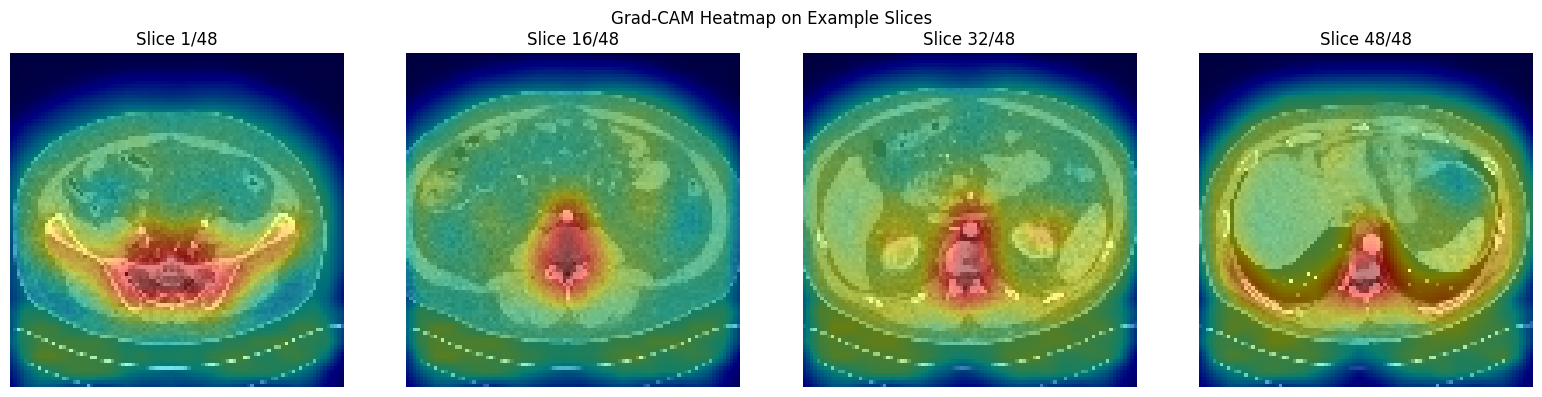

In [49]:

# ============================================
# 13) OPTIONAL: SIMPLE GRAD-CAM FOR 3D IMAGE BRANCH
# ============================================
def grad_cam_3d(model, img_sample, clin_sample, rad_sample=None, target_layer_name="conv3d_2"):
    """
    img_sample: (1,H,W,D,1)
    clin_sample: (1, C_clin)
    """
    inputs = [img_sample, clin_sample]
    if rad_sample is not None:
        inputs.append(rad_sample)

    conv_layer = model.get_layer(target_layer_name)

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(inputs, training=False)

        # FIX: Handle multi-output dict
        if isinstance(predictions, dict):
            malignancy_pred = predictions["malignancy"]
            loss = malignancy_pred[:, 0]     # (B,)
        else:
            loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(1,2,3,4), keepdims=True)
    cam = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)  # (B,H,W,D)
    cam = tf.nn.relu(cam)
    cam = cam[0].numpy()
    cam = cam / (cam.max() + 1e-8)
    return cam  # (H,W,D)


# example on one validation sample (if exists)
if X_img_va.shape[0] > 0:
    img_sample = X_img_va[0:1]          # (1,H,W,D,1)
    clin_sample = X_clin_va[0:1]        # (1,C_clin)
    rad_sample = X_rad_va[0:1] if X_rad_va is not None else None

    cam_vol = grad_cam_3d(
        model,
        img_sample,
        clin_sample,
        rad_sample,
        target_layer_name="conv3d_2"
    )
    print("Grad-CAM volume shape:", cam_vol.shape)

    # original CT volume for the same sample
    vol_np = img_sample[0, :, :, :, 0]   # (H,W,D)
    H, W, D = vol_np.shape
    Hc, Wc, Dc = cam_vol.shape

    # --- resize CAM to match image volume shape ---
    # we already imported ndzoom earlier
    zoom_factors = (
        H / float(Hc if Hc > 0 else 1),
        W / float(Wc if Wc > 0 else 1),
        D / float(Dc if Dc > 0 else 1),
    )
    cam_resized = ndzoom(cam_vol, zoom_factors, order=1)  # (H,W,D)
    cam_resized = cam_resized / (cam_resized.max() + 1e-8)

    # pick 4 slices across the depth
    indices = np.linspace(0, D - 1, 4, dtype=int)

    plt.figure(figsize=(16, 4))
    for i, d in enumerate(indices):
        plt.subplot(1, 4, i + 1)
        plt.imshow(vol_np[:, :, d], cmap="gray")
        plt.imshow(cam_resized[:, :, d], cmap="jet", alpha=0.5)
        plt.axis("off")
        plt.title(f"Slice {d+1}/{D}")
    plt.suptitle("Grad-CAM Heatmap on Example Slices")
    plt.tight_layout()
    plt.show()




Fitting SHAP KernelExplainer on clinical branch...


  0%|          | 0/2 [00:00<?, ?it/s]

Rendering SHAP summary plot...


/tmp/ipython-input-2055313869.py:63: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


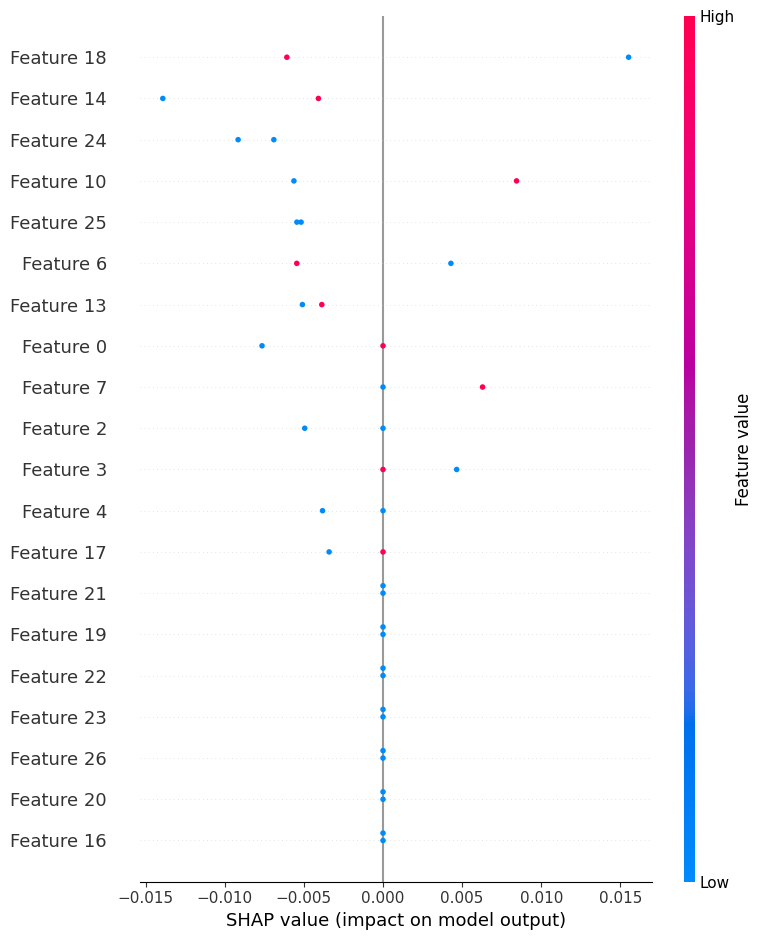

Saved SHAP summary plot to: /content/outputs/shap_clinical_summary.png


In [53]:
# ============================================
# 14) SHAP EXPLAINER FOR CLINICAL FEATURES ONLY
# ============================================
RUN_SHAP = True  # set to True when you actually want to run (can be slow)

if RUN_SHAP and X_clin_tr.shape[0] > 0:
    import shap

    # Use a small background + test subset to keep it tractable
    subset_size = min(64, X_clin_tr.shape[0])
    background_clin = X_clin_tr[:subset_size]
    test_clin = X_clin_te[:50] if X_clin_te.shape[0] >= 50 else X_clin_te

    # Dummy image and optional radiomics kept fixed while varying clinical inputs
    dummy_img = np.zeros_like(X_img_tr[:1])
    dummy_rad = np.zeros_like(X_rad_tr[:1]) if X_rad_tr is not None else None

    def clinical_only_model(clin_batch):
        """
        Wrap the multimodal Keras model so SHAP sees a clinical-only model.
        We repeat a fixed dummy image (and radiomics if present) for each row.
        Returns p(malignant) as a 1D numpy array.
        """
        B = clin_batch.shape[0]
        img_batch = np.repeat(dummy_img, B, axis=0)
        inputs = [img_batch, clin_batch]
        if dummy_rad is not None:
            rad_batch = np.repeat(dummy_rad, B, axis=0)
            inputs.append(rad_batch)

        preds = model.predict(inputs, verbose=0)

        # Handle multi-output model: extract malignancy head
        if isinstance(preds, dict):
            probs = preds["malignancy"].ravel()
        elif isinstance(preds, (list, tuple)):
            probs = preds[0].ravel()
        else:
            probs = preds.ravel()

        return probs  # shape (B,)

    print("Fitting SHAP KernelExplainer on clinical branch...")
    explainer = shap.KernelExplainer(clinical_only_model, background_clin)

    # nsamples controls runtime; 100–200 is OK for demo
    shap_values = explainer.shap_values(test_clin, nsamples=200)

    # Handle list vs array depending on SHAP version
    if isinstance(shap_values, list):
        shap_vals = shap_values[0]
    else:
        shap_vals = shap_values

    # Optional: feature names if you have them
    feature_names = globals().get("clin_feature_names", None)

    # Ensure output directory exists
    OUT_DIR = PROJECT_ROOT / "outputs"
    OUT_DIR.mkdir(exist_ok=True)

    print("Rendering SHAP summary plot...")
    shap.summary_plot(
        shap_vals,
        test_clin,
        feature_names=feature_names,
        show=False
    )
    plt.tight_layout()
    plt.savefig(OUT_DIR / "shap_clinical_summary.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved SHAP summary plot to:", OUT_DIR / "shap_clinical_summary.png")


Computing Grad-CAM for test sample 0...
Saved Grad-CAM overlay to: /content/outputs/gradcam_test_example_mid_slice.png


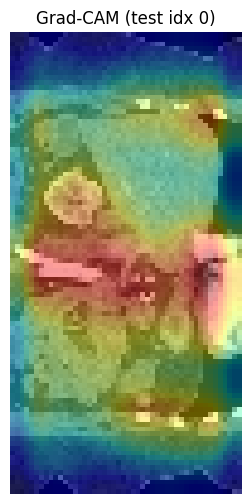

In [55]:
# ============================================
# 15) 3D GRAD-CAM FOR CT BRANCH
# ============================================
def compute_gradcam_3d(
    model,
    img_vol,
    clin_vec,
    rad_vec=None,
    layer_name="conv3d_2"
):
    """
    Compute a 3D Grad-CAM heatmap.
    """
    conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    img_batch = np.expand_dims(img_vol, axis=0)
    clin_batch = np.expand_dims(clin_vec, axis=0)
    inputs = [img_batch, clin_batch]

    if rad_vec is not None:
        rad_batch = np.expand_dims(rad_vec, axis=0)
        inputs.append(rad_batch)

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(inputs)

        # FIX FOR MULTI-OUTPUT MODEL
        if isinstance(preds, dict):
            malignancy_pred = preds["malignancy"]     # shape (1,1)
            loss = malignancy_pred[:, 0]
        else:
            loss = preds[:, 0]

    grads = tape.gradient(loss, conv_outputs)[0]
    conv_outputs = conv_outputs[0]

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs * pooled_grads

    heatmap = tf.reduce_sum(conv_outputs, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def plot_gradcam_mid_slice(
    img_vol,
    heatmap_3d,
    save_path=None,
    title="Grad-CAM (mid slice)"
):
    """
    Take a 3D CT volume and 3D Grad-CAM heatmap and overlay on the mid axial slice.
    """
    # Use mid slice in depth dimension
    d = img_vol.shape[0]
    d_cam = heatmap_3d.shape[0]
    mid_idx_img = d // 2
    mid_idx_cam = d_cam // 2

    orig_slice = img_vol[mid_idx_img, :, :, 0]   # (H, W)
    cam_slice  = heatmap_3d[mid_idx_cam, :, :]   # (h', w')

    # Resize CAM slice to match original HxW using TF (no extra deps)
    cam_slice_resized = tf.image.resize(
        cam_slice[..., np.newaxis],
        size=orig_slice.shape,
        method="bilinear"
    ).numpy()[..., 0]

    # Normalize original for visualization
    orig_min, orig_max = np.min(orig_slice), np.max(orig_slice)
    if orig_max > orig_min:
        orig_norm = (orig_slice - orig_min) / (orig_max - orig_min)
    else:
        orig_norm = orig_slice

    plt.figure(figsize=(6, 6))
    plt.imshow(orig_norm, cmap="gray")
    plt.imshow(cam_slice_resized, cmap="jet", alpha=0.4)
    plt.axis("off")
    plt.title(title)

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved Grad-CAM overlay to:", save_path)

    plt.show()


# -------- Example usage on one test patient --------
if X_img_te.shape[0] > 0:
    example_idx = 0  # pick any test index
    example_img  = X_img_te[example_idx]
    example_clin = X_clin_te[example_idx]
    example_rad  = X_rad_te[example_idx] if X_rad_te is not None else None

    print(f"Computing Grad-CAM for test sample {example_idx}...")
    heatmap_3d = compute_gradcam_3d(
        model,
        example_img,
        example_clin,
        rad_vec=example_rad,
        layer_name="conv3d_2"  # your last conv layer
    )

    OUT_DIR = PROJECT_ROOT / "outputs"
    OUT_DIR.mkdir(exist_ok=True)
    gradcam_path = OUT_DIR / "gradcam_test_example_mid_slice.png"

    plot_gradcam_mid_slice(
        example_img,
        heatmap_3d,
        save_path=str(gradcam_path),
        title=f"Grad-CAM (test idx {example_idx})"
    )


In [56]:
# ===== Cell: Drift detection and LoRA retraining =====
# IMPORTANT: This section is written for PyTorch models.
# The main model in this notebook uses TensorFlow/Keras.
# You will need to adapt this code for TensorFlow or ensure PyTorch is fully integrated.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from scipy.spatial.distance import euclidean

# reference stats from training data
ref_mean = X_clin_tr.mean(axis=0)
ref_std  = X_clin_tr.std(axis=0) + 1e-6

def compute_feature_shift(new_clin):
    new_mean = new_clin.mean(axis=0)
    new_std  = new_clin.std(axis=0) + 1e-6
    mean_shift = euclidean(ref_mean, new_mean) / len(ref_mean)
    std_shift  = euclidean(ref_std, new_std) / len(ref_std)
    return mean_shift, std_shift

DRIFT_THRESHOLD_MEAN = 0.1   # tune these thresholds
DRIFT_THRESHOLD_STD  = 0.1

def check_drift(new_clin):
    m_shift, s_shift = compute_feature_shift(new_clin)
    print(f"Mean shift: {m_shift:.4f}, Std shift: {s_shift:.4f}")
    return (m_shift > DRIFT_THRESHOLD_MEAN) or (s_shift > DRIFT_THRESHOLD_STD)

def lora_parameters(model):
    yield model.fusion_head.lora_A
    yield model.fusion_head.lora_B

def finetune_lora_on_new_data(model, new_loader, epochs=3, lr=5e-5):
    model.train()
    # freeze everything except LoRA matrices
    for p in model.parameters():
        p.requires_grad = False
    for p in lora_parameters(model):
        p.requires_grad = True

    opt = torch.optim.Adam(lora_parameters(model), lr=lr)
    crit = nn.CrossEntropyLoss()

    for ep in range(1, epochs+1):
        running_loss = 0.0
        all_labels, all_probs = [], []
        for imgs, clin, labels in new_loader:
            imgs = imgs.to(DEVICE)
            clin = clin.to(DEVICE)
            labels = labels.to(DEVICE)

            opt.zero_grad()
            logits = model(imgs, clin)
            loss = crit(logits, labels)
            loss.backward()
            opt.step()

            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(logits, dim=1)[:,1]
            all_labels.extend(labels.cpu().numpy().tolist())
            all_probs.extend(probs.detach().cpu().numpy().tolist())

        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)
        preds = (all_probs >= 0.5).astype(int)
        auc = roc_auc_score(all_labels, all_probs)
        print(f"[LoRA fine-tune] Epoch {ep} | Loss {running_loss/len(all_labels):.4f} | AUC {auc:.3f}")

    # save new LoRA state
    new_lora_state = {
        "fusion_head.lora_A": model.fusion_head.lora_A.detach().cpu(),
        "fusion_head.lora_B": model.fusion_head.lora_B.detach().cpu(),
    }
    version_id = np.random.randint(100000)
    out_path = os.path.join(MODEL_DIR, f"lora_only_v{version_id}.pt")
    torch.save(new_lora_state, out_path)
    print("Saved updated LoRA weights to", out_path)
    return out_path


In [ ]:
# ============================================
# 15) OPTIONAL (PSEUDO): DRIFT CHECK + LoRA FINE-TUNE (PYTORCH)
# ============================================
# NOTE:
# The main notebook uses TensorFlow/Keras for `model`.
# This PyTorch snippet is provided as a conceptual template only.
# Do NOT run this cell unless you replace `model` with a PyTorch model
# and implement a proper MultimodalDataset in PyTorch.

"""
from torch.utils.data import Dataset, DataLoader

class MultimodalDataset(Dataset):
    def __init__(self, X_img, X_clin, y):
        self.X_img = X_img
        self.X_clin = X_clin
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = torch.tensor(self.X_img[idx], dtype=torch.float32)
        clin = torch.tensor(self.X_clin[idx], dtype=torch.float32)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return img, clin, label

# Example: new incoming batch (already preprocessed like training data)
# X_img_new: (N_new, D, H, W, C)
# X_clin_new: (N_new, C_clin)
# y_new: (N_new,)
new_ds = MultimodalDataset(X_img_new, X_clin_new, y_new)
new_loader = DataLoader(new_ds, batch_size=BATCH_SIZE, shuffle=True)

if check_drift(X_clin_new):
    print("Drift detected. Fine-tuning LoRA layers...")
    lora_path_new = finetune_lora_on_new_data(model, new_loader)
else:
    print("No significant drift detected.") TODO add daatset class in train/valset
"""


In [58]:

# 16) SINGLE-PATIENT INFERENCE HELPER
# ============================================
from tensorflow.keras.models import load_model
full_model_path="/content/drive/MyDrive/capstone/tumor_pred_ai/models/multimodal_lora_full_model.h5"

# Reload model (e.g., in a fresh session)
custom_objects = {"LoRADense": LoRADense}
inference_model = load_model(full_model_path, custom_objects=custom_objects)
print("Loaded model for inference from:", full_model_path)

def predict_patient(
    model,
    img_vol,
    clin_features,
    rad_features=None,
    threshold=0.5,
):
    """
    img_vol:       3D CT volume already preprocessed to same shape as X_img (H,W,D,1)
    clin_features: 1D array of scaled clinical features (same order as X_clin_scaled columns)
    rad_features:  1D array of scaled radiomics features (or None if not used)
    """

    img = np.asarray(img_vol, dtype="float32")
    clin = np.asarray(clin_features, dtype="float32")

    # add batch dimension
    img  = np.expand_dims(img, axis=0)   # (1, H, W, D, 1)
    clin = np.expand_dims(clin, axis=0)  # (1, C_clin)

    inputs = [img, clin]

    if rad_features is not None:
        rad = np.asarray(rad_features, dtype="float32")
        rad = np.expand_dims(rad, axis=0)  # (1, C_rad)
        inputs.append(rad)

    preds = model.predict(inputs, batch_size=1, verbose=0)

    # IMPORTANT: handle multi-output dict
    if isinstance(preds, dict):
        probs = preds["malignancy"].ravel()
    elif isinstance(preds, (list, tuple)):
        probs = preds[0].ravel()
    else:
        probs = preds.ravel()

    prob = float(probs[0])
    label = int(prob >= threshold)

    return prob, label


# Example: run inference on one test patient
example_idx = 0
example_img  = X_img_te[example_idx]
example_clin = X_clin_te[example_idx]
example_rad  = X_rad_te[example_idx] if X_rad_te is not None else None

prob, label = predict_patient(inference_model, example_img, example_clin, example_rad)
print(f"Malignancy probability: {prob:.3f}  -> Predicted label: {label}")


Loaded model for inference from: /content/drive/MyDrive/capstone/tumor_pred_ai/models/multimodal_lora_full_model.h5
Malignancy probability: 0.610  -> Predicted label: 1


In [61]:
# streamlit_app.py
import numpy as np
import streamlit as st
from pathlib import Path
from tensorflow.keras.models import load_model

# Import your custom LoRA layer from the same module / copy class definition



# ----- CONFIG -----
PROJECT_ROOT = Path("/content/drive/MyDrive/capstone/tumor_pred_ai")  # adjust if needed
MODEL_DIR = PROJECT_ROOT / "models"
FULL_MODEL_PATH = MODEL_DIR / "multimodal_lora_full_model.h5"

# If you saved scalers, load them here:
# import joblib
# clin_scaler = joblib.load(MODEL_DIR / "clin_scaler.pkl")
# rad_scaler  = joblib.load(MODEL_DIR / "rad_scaler.pkl")

@st.cache_resource
def load_inference_model():
    custom_objects = {"LoRADense": LoRADense}
    model = load_model(FULL_MODEL_PATH, custom_objects=custom_objects)
    return model

def predict_patient(model, img_vol, clin_features, rad_features=None, threshold=0.5):
    img = np.asarray(img_vol, dtype="float32")
    clin = np.asarray(clin_features, dtype="float32")

    img  = np.expand_dims(img, axis=0)   # (1, D, H, W, 1)
    clin = np.expand_dims(clin, axis=0)  # (1, C_clin)

    inputs = [img, clin]

    if rad_features is not None:
        rad = np.asarray(rad_features, dtype="float32")
        rad = np.expand_dims(rad, axis=0)
        inputs.append(rad)

    outputs = model.predict(inputs, batch_size=1).ravel()[0]
    if isinstance(outputs, dict):
      prob = float(outputs["malignancy"].ravel()[0])
    elif isinstance(outputs, (list, tuple)):
      prob = float(outputs[0].ravel()[0])
    else:
      prob = float(outputs.ravel()[0])
    label = int(prob >= threshold)
    return prob, label

# ============ STREAMLIT UI ============
st.title("Kidney Tumor Multimodal Predictor ")
st.write("CT volume + clinical features (and optional radiomics) → malignancy probability.")

model = load_inference_model()

st.sidebar.header("Clinical Features")
# Example clinical inputs – replace with your real feature names/ranges
age = st.sidebar.number_input("Age at nephrectomy", min_value=0, max_value=120, value=60)
bmi = st.sidebar.number_input("Body Mass Index", min_value=10.0, max_value=60.0, value=25.0)
rad_size = st.sidebar.number_input("Radiographic size (cm)", min_value=0.0, max_value=30.0, value=5.0)

# Build clinical feature vector in the same order as X_clin_scaled columns
# Here is just an example; adapt to your actual order!
clin_vec_raw = np.array([age, bmi, rad_size], dtype="float32")

# If you used a scaler during training, apply it:
# clin_vec = clin_scaler.transform(clin_vec_raw.reshape(1, -1)).ravel()
clin_vec = clin_vec_raw  # if already scaled or using raw in demo

st.header("CT Volume Input")
st.write("For now, upload a preprocessed NumPy `.npy` volume with shape `(D, H, W, 1)`.")

uploaded_file = st.file_uploader("Upload CT volume (.npy)", type=["npy"])

rad_vec = None
# If you want radiomics input via UI you can add numeric fields here
# or load from a file:
# rad_uploaded = st.file_uploader("Upload radiomics features (.npy)", type=["npy"])
# if rad_uploaded is not None:
#     rad_vec = np.load(rad_uploaded)

if uploaded_file is not None:
    img_vol = np.load(uploaded_file)
    st.write(f"Loaded volume shape: {img_vol.shape}")

    if st.button("Run Prediction"):
        prob, label = predict_patient(model, img_vol, clin_vec, rad_vec)
        st.subheader("Results")
        st.write(f"**Malignancy probability:** {prob:.3f}")
        st.write(f"**Predicted label:** {'Malignant' if label == 1 else 'Benign'}")
else:
    st.info("Upload a `.npy` CT volume to enable prediction.")


2025-11-22 16:29:13.508 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 16:29:13.593 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-11-22 16:29:13.593 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 16:29:13.594 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 16:29:13.595 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 16:29:13.595 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 16:29:13.596 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 16:29:13.597 Thread 'MainThread': mi

In [74]:
import datetime
import os
import shutil

# Define the function first
def savemodels_and_outputs(source_dir_path, dest_base_dir_path):
    # Get current timestamp
    timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M%S")
    DEST_FINAL_DIR = os.path.join(dest_base_dir_path, timestamp)

    # Create the destination directory if it doesn't exist
    os.makedirs(DEST_FINAL_DIR, exist_ok=True)

    # Copy the contents of the source directory to the new timestamped destination directory
    for item in os.listdir(source_dir_path):
        s = os.path.join(source_dir_path, item)
        d = os.path.join(DEST_FINAL_DIR, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)

    print(f"Copied contents from {source_dir_path} to {DEST_FINAL_DIR}")

# Define source and destination paths
SOURCE_MODEL_DIR_GLOBAL = "/content/models"
DEST_MODELS_BASE_DIR_GLOBAL = "/content/drive/MyDrive/capstone/tumor_pred_ai/models"
savemodels_and_outputs(SOURCE_MODEL_DIR_GLOBAL, DEST_MODELS_BASE_DIR_GLOBAL)


SOURCE_OUT_DIR_GLOBAL = "/content/outputs"
DEST_OUT_BASE_DIR_GLOBAL = "/content/drive/MyDrive/capstone/tumor_pred_ai/outputs"
savemodels_and_outputs(SOURCE_OUT_DIR_GLOBAL, DEST_OUT_BASE_DIR_GLOBAL)

Copied contents from /content/models to /content/drive/MyDrive/capstone/tumor_pred_ai/models/20251122164445
Copied contents from /content/outputs to /content/drive/MyDrive/capstone/tumor_pred_ai/outputs/20251122164445
